In [8]:
import sys
import os 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import json
from SYK_fft import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from ConformalAnalytical import *
from scipy.signal import find_peaks
import matplotlib.ticker as tck
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})
# plt.style.use('../Figuremaker/physrev.mplstyle') # Set full path to if physrev.mplstyle is not in the same in directory as the notebook
plt.rcParams['legend.fontsize'] = '8'
plt.rcParams['figure.titlesize'] = '8'
plt.rcParams['axes.titlesize'] = '8'
plt.rcParams['axes.labelsize'] = '8'
# plt.rcParams['figure.figsize'] = f'{3.25*2},{3.25*2}'
plt.rcParams['lines.markersize'] = '6'
plt.rcParams['lines.linewidth'] = '1'
plt.rcParams['axes.formatter.limits'] = '-2,2'
plt.rcParams['text.usetex'] = 'True'
plt.rcParams['text.latex.preamble']=r"\usepackage{amsmath}"
path_ = './mwh_files'

In [9]:
DUMP = False

M = int(2**20) #number of points in the grid
T = 2**16 #upper cut-off for the time
#err = 1e-5
err = 1e-5


omega,t  = RealGridMaker(M,T)
dw = omega[2] - omega[1]
dt = t[2] - t[1]

print("dw = ", dw)
print("dt = ", dt)
print('omega max', np.max(omega))

delta = 0.420374134464041
ITERMAX = 15000 #changed this from 5000; this is because x is changed (x lower-> convergence is slower)!
global beta

mu = 0.0
g = .5
r = 1.
kappa = 1.
eta = dw*20.1
print("eta = ", eta)


grid = [M,omega,t]
pars = [g,mu,r]




dw =  4.793689962667713e-05
dt =  0.0625
omega max 50.26543452053707
eta =  0.0009635316824962104


In [10]:
#Loading imaginary time results from Aravindh

#Open and load the JSON file
with open('main_panel.json', 'r') as file:
    data = json.load(file)

with open('inset.json', 'r') as f_inset:
    inset_data = json.load(f_inset)

child0_x = data["_child0"]["x"]
child0_y = data["_child0"]["y"]

child1_x = data["_child1"]["x"]
child1_y = data["_child1"]["y"]

fit_g_x = data["$\\Delta_{\\text{fit}}^G$= 0.79"]["x"]
fit_g_y = data["$\\Delta_{\\text{fit}}^G$= 0.79"]["y"]

fit_d_x = data["$\\Delta_{\\text{fit}}^D$= 0.85"]["x"]
fit_d_y = data["$\\Delta_{\\text{fit}}^D$= 0.85"]["y"]

inset_x = inset_data["numerics DDtau"]["x"]
inset_y = inset_data["numerics DDtau"]["y"]
inset_x_G = inset_data["numerics GDtau"]["x"]
inset_y_G = inset_data["numerics GDtau"]["y"]


/var/folders/0k/tbvb8hxj7217q619l3k1zz5w0000gn/T/ipykernel_26815/3102867327.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(fit_g_x, fit_g_y, 'r-', label='$\\Delta_{\\text{fit}}^G$= 0.79', c ='tab:blue')
/var/folders/0k/tbvb8hxj7217q619l3k1zz5w0000gn/T/ipykernel_26815/3102867327.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(fit_d_x, fit_d_y, 'g-', label='$\\Delta_{\\text{fit}}^D$= 0.85', c ='tab:orange')
/var/folders/0k/tbvb8hxj7217q619l3k1zz5w0000gn/T/ipykernel_26815/3102867327.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax_inset.plot(inset_x, inset_y, 'k-', label='Numerics DDtau', c= 'tab:orange')
/var/folders/0k/t

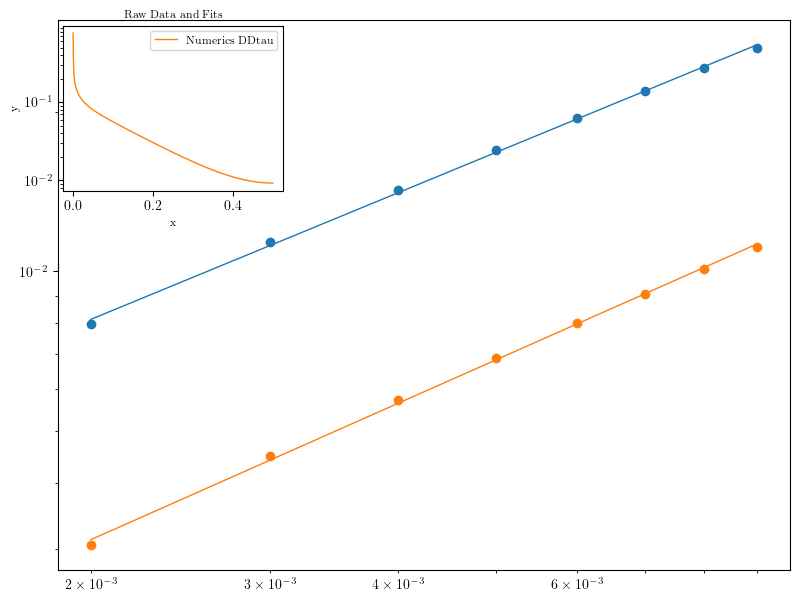

In [11]:
plt.figure(figsize=(8, 6))

# Plot raw data
plt.scatter(child0_x, child0_y,  label='Child 0', c='tab:blue')
plt.scatter(child1_x, child1_y,  label='Child 1', c ='tab:orange')

# Plot fits
plt.plot(fit_g_x, fit_g_y, 'r-', label='$\\Delta_{\\text{fit}}^G$= 0.79', c ='tab:blue')
plt.plot(fit_d_x, fit_d_y, 'g-', label='$\\Delta_{\\text{fit}}^D$= 0.85', c ='tab:orange')
plt.semilogx()  # Use logarithmic scale for x-axis
plt.semilogy()
# Plot inset data
ax_inset = inset_axes(plt.gca(), width="30%", height="30%", loc='upper left')
ax_inset.plot(inset_x, inset_y, 'k-', label='Numerics DDtau', c= 'tab:orange')
#don't want a log-log inset
ax_inset.semilogy()  # Use logarithmic scale for y-axis only
# ax_inset.set_yscale('linear')


plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.title('Raw Data and Fits')
plt.tight_layout()
plt.show()

64.8888888888889 mwh_M20T16beta64_9g0_5r1_0lamb0_1J0_0eta240_1.npy
[0.13801033 0.29927006 0.40511474 0.52577192 1.19794312] peaks
146.0 mwh_M20T16beta146_0g0_5r1_0lamb0_05J0_0eta240_1.npy


/Users/jaspersteenbergen/Desktop/TwoSidedYSYK-main-Aravindh/Submission/SYK_fft.py:87: RuntimeWarning: overflow encountered in exp
  return (1.0/(1.0 + np.exp(arg)))


2393.2800000000066 mwh_M20T16beta2393_3g0_5r1_0lamb0_005J0_0eta195_1.npy


/var/folders/0k/tbvb8hxj7217q619l3k1zz5w0000gn/T/ipykernel_26815/3473141140.py:222: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(loc='lower right',bbox_to_anchor=(1, 0.1) )


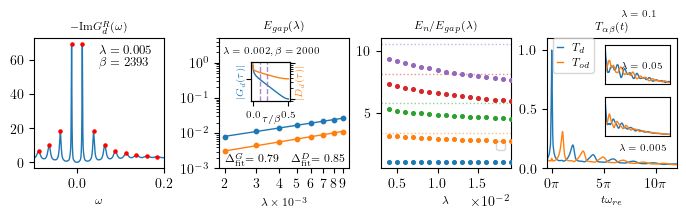

In [13]:
lamb = 0.05
J = 0.0
target_beta = 4
lambda_step = 0.001
beta = 146.0 

epsilon = 0.005/2 #/2
err = 1e-1 * ((epsilon)**2)
grid = [M,omega,t]
g = 0.5
eta = dw*240.1
pars = [g,mu,r]


p0_list = []
p1_list = []
gap_list = []
boson_gap_list = []
lamb_list = []
fig, ax = plt.subplots(1,4, constrained_layout=True)
fig.set_size_inches(2*3.375, 3.375)

while beta > target_beta:
    savefile = 'mwh_' +'M' + str(int(np.log2(M))) + 'T' + str(int(np.log2(T))) 
    savefile += 'beta' + str(round(beta,1)) 
    savefile += 'g' + str(g) + 'r' + str(r) + 'lamb' + str(round(lamb,4)) +'J'+ str(round(J,3)) + 'eta'+str(round(eta/dw,3))
    savefile = savefile.replace('.','_') 
    savefile +=  '.npy'
    GFs = np.load(os.path.join(path_, savefile))
    
    #find peaks in spectral function
    peaks, _ = find_peaks(-np.imag(GFs[0]), prominence=.3, height=.1)
    omega_peaks = omega[peaks][omega[peaks]>0]
    bosonpeaks, _ = find_peaks(np.imag(GFs[2]), prominence=.3, height=.1)
    omega_bosonpeaks = omega[bosonpeaks][omega[bosonpeaks]>0]
  
    if len(omega_peaks) >= 1: # and lamb < 0.02:
        gap = omega_peaks[0]
        gap_list.append(gap)
        boson_gap = omega_bosonpeaks[0]
        boson_gap_list.append(boson_gap)
        p1, p0 = np.polyfit([0,1],omega_peaks[0:2],1 )
        p0_list.append(p0/gap)
        p1_list.append(p1/gap)
        lamb_list.append(lamb)

    if (round(lamb,4)) == 0.1:
        print(beta, savefile)
        rhoGD = -np.imag(GFs[0])
        rhoGOD = -np.imag(GFs[1])
        p1, p0 = np.polyfit([0,1],omega_peaks[0:2],1 )
        omega_re = p1
        print(omega_peaks, 'peaks')
        G_GD = (1-fermidirac(omega*11))*rhoGD
        G_OD = (1-fermidirac(omega*11))*rhoGOD

        G_GDt = freq2time(G_GD,M,dt)
        G_ODt = freq2time(G_OD,M,dt)

        axins = ax[3].inset_axes([0.45, 0.65, 0.5, 0.3])
        axins.plot(t*omega_re/np.pi, 2*np.abs(G_GDt)/np.pi, c='tab:blue', label = '$T_{GD}$')
        axins.plot(t*omega_re/np.pi, 2*np.abs(G_ODt)/np.pi, c='tab:orange', label = '$T_{OD}$')
        axins.set_xlim(0, 12)
        axins.set_ylim(0, 1.1)
        axins.set_xticks([])
        axins.set_yticks([])
        axins.text(3,1.9, '$\lambda = 0.1$', fontsize=7)
        
    if (round(lamb,3)) <= 0.008:
        lambda_step = 0.0005

 
       
    beta_step = (beta/lamb)*lambda_step
    if lamb >=0.05:
        lambda_step = 0.005
        beta_step = beta/((lamb/lambda_step)-1)
    
    if lamb >=0.3:
        lambda_step = 0.05
        beta_step = beta/((lamb/lambda_step)-1)



    beta -= beta_step
    lamb += lambda_step

beta = 146.0
target_beta = 3682
lamb=0.05
lambda_step = 0.001

while beta < target_beta:                       
    if round(lamb, 4) == 0.008:
        beta = 1495.8                       #----> fiddling with rounding errors
        eta = 204.1*dw
    if round(lamb, 4) == 0.0047:
        beta = 2519.3
    if round(lamb, 4) == 0.0045:
        beta = 2659.2
    if round(lamb, 4) == 0.0035:
        beta = 3418.9
    savefile = 'mwh_' +'M' + str(int(np.log2(M))) + 'T' + str(int(np.log2(T))) 
    savefile += 'beta' + str(round(beta,1)) 
    savefile += 'g' + str(g) + 'r' + str(r) + 'lamb' + str(round(lamb,4)) +'J'+ str(round(J,3)) + 'eta'+str(round(eta/dw,3))
    savefile = savefile.replace('.','_') 
    savefile +=  '.npy'
    GFs = np.load(os.path.join(path_, savefile))
    
    peaks, _ = find_peaks(-np.imag(GFs[0]), prominence=.3, height=.1)
    omega_peaks = omega[peaks][omega[peaks]>0]

    bosonpeaks, _ = find_peaks(np.imag(GFs[2]), prominence=.3, height=.1)
    omega_bosonpeaks = omega[bosonpeaks][omega[bosonpeaks]>0]
    
    if len(omega_peaks) >= 5: # and lamb < 0.02:
        gap = omega_peaks[0]
        gap_list.append(gap)
        boson_gap = omega_bosonpeaks[0]
        boson_gap_list.append(boson_gap)
        p1, p0 = np.polyfit([0,1,2,3],omega_peaks[0:4],1 )
        p0_list.append(p0/gap)
        p1_list.append(p1/gap)
        lamb_list.append(lamb)

        if (round(lamb, 4)*1000 % 1) == 0:
            ax[2].scatter(lamb, omega_peaks[0]/gap, c='tab:blue', marker='o', s = 7, zorder = 10)
            ax[2].scatter(lamb, omega_peaks[1]/gap, c='tab:orange', marker='o', s = 7, zorder = 10)
            ax[2].scatter(lamb, omega_peaks[2]/gap, c='tab:green', marker='o', s = 7, zorder = 10)
            ax[2].scatter(lamb, omega_peaks[3]/gap, c='tab:red', marker='o', s = 7, zorder = 10)
            ax[2].scatter(lamb, omega_peaks[4]/gap, c='tab:purple', marker='o', s = 7, zorder = 10)

    if (round(lamb,4)) == 0.005:
        print(beta, savefile)
        ax[0].plot(omega, -np.imag(GFs[0]), color='tab:blue', zorder=1)
        ax[0].scatter(omega[peaks], -np.imag(GFs[0][peaks]),c= 'r', s = 5, zorder=2)
        ax[0].set_xlim(-.1, 0.2)
        ax[0].set_xlabel(r'$\omega$')
        ax[0].set_title(r'$-\text{Im}G_d^R(\omega)$')
        ax[0].set_box_aspect(1)
        textstr = '\n'.join((r'$\lambda=%.3f$' % (lamb, ),
            r'$\beta=%.0f$' % (beta, )))
        
        ax[0].text(.5, 0.95, textstr, transform=ax[0].transAxes, fontsize=9,
        verticalalignment='top')
        rhoGD = -np.imag(GFs[0])
        rhoGOD = -np.imag(GFs[1])

        G_GD = (1-fermidirac(omega*2392.3))*rhoGD
        G_OD = (1-fermidirac(omega*2392.3))*rhoGOD

        G_GDt = freq2time(G_GD,M,dt)
        G_ODt = freq2time(G_OD,M,dt)
        omega_re = p1
        ax[3].plot(t*omega_re/np.pi, 2*np.abs(G_GDt)/np.pi, c='tab:blue', label = '$T_{d}$')
        ax[3].plot(t*omega_re/np.pi, 2*np.abs(G_ODt)/np.pi, c='tab:orange', label = '$T_{od}$')
        ax[3].set_xlim(-.5, 12)
        ax[3].set_ylim(0, 1.1)
        ax[3].set_title(r'$T_{\alpha\beta}(t)$')
        ax[3].set_box_aspect(1)
        ax[3].legend(handlelength = .5, loc='upper left', bbox_to_anchor=(0.05, 1), borderaxespad=0)
        ax[3].set_xlabel(r'$t\omega_{re}$')
        ax[3].xaxis.set_major_formatter(tck.FormatStrFormatter('%g$\pi$'))
        ax[3].xaxis.set_major_locator(tck.MultipleLocator(base=5.0))
        ax[3].text(6.5,.15, '$\lambda = 0.005$', fontsize=7)

    if (round(lamb,4)) == 0.05:
        print(beta, savefile)
        p1, p0 = np.polyfit([0,1,2],omega_peaks[0:3],1 )
        omega_re = p1
        rhoGD = -np.imag(GFs[0])
        rhoGOD = -np.imag(GFs[1])

        G_GD = (1-fermidirac(omega*146))*rhoGD
        G_OD = (1-fermidirac(omega*146))*rhoGOD

        G_GDt = freq2time(G_GD,M,dt)
        G_ODt = freq2time(G_OD,M,dt)
        #inset on axis 3:
        axins2 = ax[3].inset_axes([0.45, 0.25, 0.5, 0.3]) # [x0, y0, width, height]
        axins2.plot(t*omega_re/np.pi, 2*np.abs(G_GDt)/np.pi, c='tab:blue', label = '$T_{GD}$')
        axins2.plot(t*omega_re/np.pi, 2*np.abs(G_ODt)/np.pi, c='tab:orange', label = '$T_{OD}$')
        axins2.set_xlim(0, 12)
        axins2.set_ylim(0, 1.1)
        axins2.set_xticks([])
        axins2.set_yticks([])
        axins2.text(3,1.9, '$\lambda = 0.05$', fontsize=7)
    
    if (round(lamb,4)) <= 0.01:
        lambda_step = 0.0005
    if (round(lamb,3)) <= 0.0065:
        lambda_step = 0.00025
    
    beta_step = (beta/lamb)*lambda_step
    if round(lamb, 4) == 0.03:
        beta = 240.19354838709668
    if lamb <= 0.02:
        beta_step = beta/((lamb/lambda_step)-1)

    beta += beta_step
    lamb -= lambda_step
    if lamb < 0.019:
        if lamb > 0.008:
            eta_step = 2*dw
        if lamb <= 0.008:
            eta_step = 1*dw
        eta -= eta_step


for n in [1, 2, 3, 4]:
    if n ==1:
        ax[2].axhline(1+(n/delta), c='tab:orange', ls=':', zorder = 1, alpha = 0.5)
  

    if n ==2:
        ax[2].axhline(1+(2/delta), c='tab:green', ls=':', zorder = 1, alpha = 0.5)
    if n ==3:
        ax[2].axhline(1+(3/delta), c='tab:red', ls=':',    zorder = 1,  alpha = 0.5)
    if n ==4:   
        ax[2].axhline(1+(4/delta), c='tab:purple', ls=':', zorder = 1,   alpha = 0.5)

ax[2].legend(loc='lower right',bbox_to_anchor=(1, 0.1) )
ax[2].set_xlabel(r'$\lambda$')
ax[2].set_title(r'$E_n/E_{gap}(\lambda)$')
ax[2].set_xlim(0.003, 0.019)
ax[2].set_box_aspect(1)


ax[1].set_box_aspect(1)
ax[1].set_xlabel(r'$\lambda$')
ax[1].set_title('$E_{gap}(\lambda)$')

# Plot raw data
ax[1].scatter(child0_x, child0_y, s =10, c='tab:blue')
ax[1].scatter(child1_x, child1_y, s=10,  c ='tab:orange')

# Plot fits
ax[1].plot(fit_g_x, fit_g_y, label='$\\Delta_{\\text{fit}}^G$= 0.79', c ='tab:blue')
ax[1].plot(fit_d_x, fit_d_y, label='$\\Delta_{\\text{fit}}^D$= 0.85', c ='tab:orange')

# add inset
axins = ax[1].inset_axes([0.25, 0.52, 0.3, 0.3]) # [x0, y0, width, height]
axins.plot(inset_x_G, inset_y_G, label='Numerics GDtau', c= 'tab:blue')
axins.plot(inset_x, inset_y, label='Numerics DDtau', c= 'tab:orange')
#two vertical lines at x=0.1 and 0.2
axins.axvline(x=0.1, color='tab:purple', linestyle='--', alpha=0.8)
axins.axvline(x=0.2, color='tab:purple', linestyle='--', alpha=0.8)

#create twin axis for inset
axins2 = axins.twinx()
axins.semilogy() 
axins2.semilogy()
axins.tick_params(axis='x', labelsize=7)
axins.set_yticklabels([])
axins2.set_yticklabels([])
axins.set_xlabel(r'$\tau/\beta$', fontsize=7, labelpad=-3)
axins.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False)
axins2.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False)
axins2.set_ylabel(r'$|D_{d}(\tau)|$', c = 'tab:orange', fontsize=7, labelpad=-3)
axins.set_ylabel(r'$|G_{d}(\tau)|$', c = 'tab:blue', fontsize=7, labelpad=-3)
axins.set_title(r'$\lambda = 0.002, \beta = 2000$', fontsize=7)
 


ax[1].semilogx()
ax[1].semilogy()
ax[1]. set_ylim(1e-3, 5)
textstr = '$\\Delta_{\\text{fit}}^G$= 0.79$\quad\\Delta_{\\text{fit}}^D$= 0.85'
ax[1].text(0.05, 0.05, textstr, transform=ax[1].transAxes, fontsize=8)

# Custom tick locations (linear in appearance)
xticks = [0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009]
ax[1].set_xticks(xticks)

# Format ticks: multiply by 1e3 and show plain numbers
formatter = FuncFormatter(lambda val, pos: f"{val * 1e3:.0f}")
ax[1].xaxis.set_major_formatter(formatter)
ax[1].set_xlabel(r'$\lambda \times 10^{-3}$', fontsize=8)
ax[1].set_xlabel(r'$\lambda \times 10^{-3}$', fontsize=8)




# ax[3].text(0.006, 0.11, textstr, fontsize=11)


# plt.tight_layout()
plt.savefig('wormholeplots_upd_combined.pdf')
plt.show()
plt.close()








